In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [14]:
load_dotenv()

True

In [15]:
model=ChatOpenAI()

We have to create AI workflow in which a LLM generate the outline on the given topic 
Then genarate essay on it , after that it evaluate the generated essay.

Three LLM Chaining would be required for this automated workflow.


In [16]:
## Create States
class LLMState(TypedDict):
    topic: str
    outline: str
    essay: str
    feedback: str
    

In [ ]:
def topic_outline(state: LLMState)->LLMState:
    ## extarct topic
    topic=state['topic']

    ## form a prompt
    prompt= f"Generate a short essay outline for the given topic : {topic}"

    ## generate outline
    outline=model.invoke(prompt).content

    ## update state
    state['outline']=outline

    return state



In [ ]:
def essay_writing(state: LLMState)->LLMState:
    ## fetch outline
    outline=state['outline']
    ## genearate prompt
    prompt=f"Generate an essay in 100 words based on the given outline: {outline}"
    ## generate answer 
    essay=model.invoke(prompt).content
    ## Update state
    state['essay']=essay

    return state

In [25]:
def feedback(state:LLMState)->LLMState:
    ## fetch essay
    essay=state['essay']
    ## Generate prompt
    prompt=f"Generate a short feedback for the given essay: {essay}"
    ## genearate feedback
    feedback=model.invoke(prompt).content
    ## save state
    state['feedback']=feedback

    return state

In [26]:
## Create a Graph
graph=StateGraph(LLMState)

## add nodes
graph.add_node('topic_outline', topic_outline)
graph.add_node('essay_writing', essay_writing)
graph.add_node('feedback', feedback)

## add edges
graph.add_edge(START, 'topic_outline')
graph.add_edge('topic_outline', 'essay_writing')
graph.add_edge('essay_writing', 'feedback')
graph.add_edge('feedback', END)

workflow=graph.compile()

LangGraph internally tracks nodes like:
{
  "topic_outline": <function>,
  "essay_writing": <function>,
  "feedback": <function>
}

In [27]:
initial_state={'topic':'EV in India'}
final_state=workflow.invoke(initial_state)


In [32]:
print(final_state['outline'].content)

I. Introduction
    A. Definition of EV (electric vehicles)
    B. Overview of the rising popularity of EVs worldwide
II. Importance of EV in India
    A. Economic benefits 
        1. Reduction in fuel costs
        2. Job creation in the EV industry
    B. Environmental benefits
        1. Reduction in pollution levels
        2. Contribution to India's climate change goals
III. Current state of EV in India
    A. Government initiatives and policies promoting EV adoption
    B. Challenges faced by the EV industry in India
IV. Future prospects of EV in India
    A. Growth potential of the EV market in India
    B. Technological advancements shaping the future of EVs in India
V. Conclusion
    A. Summary of key points
    B. Importance of continued effort towards promoting EV adoption in India.


In [31]:
print(final_state['essay'].content)

Electric vehicles (EVs) have become increasingly popular worldwide, including in India. The economic benefits of EVs in India are vast, from reducing fuel costs to creating jobs in the EV industry. Additionally, EVs offer significant environmental benefits by lowering pollution levels and aiding India in achieving its climate change goals. Despite governmental support and policies promoting EV adoption, the industry faces challenges. However, the future looks promising with the growing potential of the EV market in India and technological advancements shaping the sector. Continued efforts towards promoting EV adoption are crucial for India's sustainable growth and environmental well-being.


In [34]:
print(final_state['feedback'])

The essay effectively highlights the economic and environmental benefits of Electric Vehicles (EVs) in India. It acknowledges the challenges faced by the industry but remains optimistic about the future due to technological advancements. Continued efforts to promote EV adoption are crucial for sustainable growth and environmental well-being in the country. Well-written and informative.


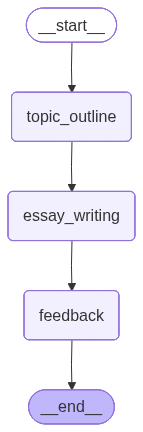

In [35]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())